In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, load_gbs_gesis, load_gbs_allensbach
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest, train_feature_weighted_decision_tree
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import sample
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs_without_cv, mrs
from utils.metrics import compute_classification_metrics_random_forest, compute_classification_metrics_tree, compute_classification_metrics_boosting

2024-04-30 17:18:50.147204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-30 17:18:51.299499: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def compute_feature_weights_softmax(budget, feature_importance):
    weights =  np.exp(-feature_importance / budget)
    return weights / np.sum(weights)

def compute_feature_weights(budget, feature_importance):
    max_importance = np.max(feature_importance)
    feature_importance = feature_importance / max_importance 
    scaled_feature_importance = feature_importance * budget
    scaled_feature_importance = 1 - scaled_feature_importance
    return scaled_feature_importance / np.sum(scaled_feature_importance)

In [3]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
##N = df[df["label"] == 1]
#R = df[df["label"] == 0]
N, R = sample(
           "less_negative_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [4]:
drop_ids, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
_, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

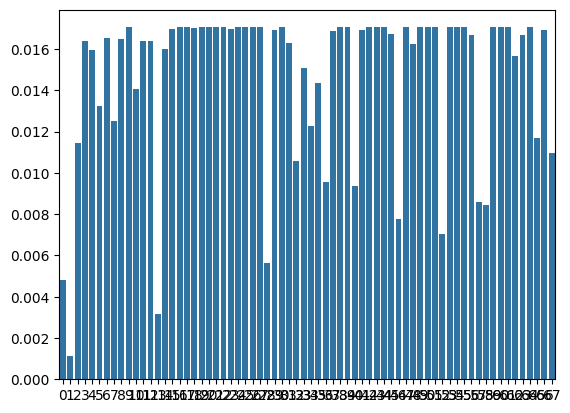

In [5]:
weights = compute_feature_weights_softmax(0.01, feature_importance_cv)
sns.barplot(weights)

In [6]:
seed = 5
max_features = "sqrt"
# budgets = [0, 0.1, 0.25, 0.5, 0.75, 0.9]
budgets = [1, 0.1, 0.05, 0.005, 0.0005]
auroc_method = train_feature_weighted_random_forest
sample_weights = np.ones(len(N))

feature_weights_list = []
for budget in budgets:
    feature_weights = compute_feature_weights_softmax(budget, feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [13]:
for i, budget in enumerate(budgets):
   auroc = compute_test_metrics_fw_mrs(
       dropped_N,
       R,
       columns,
       random_state=seed,
       feature_weights=feature_weights_list[i],
       method=auroc_method,
       draw_with_feature_weights=True,
       class_weight=None,
       max_features=5,
       splitter="feature_weighted_best",
       n_splits_test=10,
       n_estimators=250,
   )
   print(f"{budget}: {auroc:2f}")

1: 0.624733
0.1: 0.622593
0.05: 0.622703
0.005: 0.602798
0.0005: 0.560209


1: 0.624104\
0.1: 0.623239\
0.05: 0.621805\
0.005: 0.596767\
0.0005: 0.555094

In [8]:
for i,budget in enumerate(budgets):
    feature_weights = feature_weights_list[i]
    auroc, auprc = compute_classification_metrics_random_forest(
            N,
            R,
            columns,
            sample_weights,
            feature_weights,
            target,
            random_state=seed,
            draw_with_feature_weights=True,
            class_weight=None,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=1000,
            max_depth=None,
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

1 Auroc: 0.8453985024641483
1 AUPRC: 0.8067712822077531

0.1 Auroc: 0.8426699577934299
0.1 AUPRC: 0.804235102365484

0.05 Auroc: 0.8427177363797131
0.05 AUPRC: 0.8055205324263669

0.005 Auroc: 0.7805397172411612
0.005 AUPRC: 0.74290723088198

0.0005 Auroc: 0.7317558436762136
0.0005 AUPRC: 0.652428931947127



1 Auroc: 0.8004017275187225\
1 AUPRC: 0.751257336593792

0.1 Auroc: 0.7949659448441417\
0.1 AUPRC: 0.7543966321965846

0.05 Auroc: 0.7936458999839232\
0.05 AUPRC: 0.7433234384156576

0.005 Auroc: 0.7825825746330572\
0.005 AUPRC: 0.7420097481320753

0.0005 Auroc: 0.6684363037194339\
0.0005 AUPRC: 0.6127809622869232

In [20]:
for i,budget in enumerate(budgets):
    auroc, auprc = compute_classification_metrics_tree(
            N,
            R,
            columns,
            sample_weights,
            feature_weights_list[i],
            target,
            random_state=seed,
            draw_with_feature_weights=True,
            n_splits=10,
            splitter="feature_weighted_best",
            max_features="sqrt",
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

1 Auroc: 0.7367148089728186
1 AUPRC: 0.6162899076386466

0.1 Auroc: 0.7696939781548557
0.1 AUPRC: 0.6545947282344413

0.05 Auroc: 0.6446173871440738
0.05 AUPRC: 0.5405616733582642

0.005 Auroc: 0.5705915699204099
0.005 AUPRC: 0.49142676126198853

0.0005 Auroc: 0.5
0.0005 AUPRC: 0.4532



In [10]:
# dropped_N = dropped_N.drop(drop_ids)